As the Dual problem is formulated as

$$
\max_{f, g \in \R^{m}} \langle f, \mu \rangle + \langle g, \nu \rangle - \varepsilon \sum_{i, k} \left\{ \frac{f_i + g_k - C_{i k}}{\varepsilon} \right\} ,
$$
the **Entropic Barycenter Objective in Dual** reads as
$$
\min_{\nu}
    \sum_{j=1}^{n} \lambda_j
        \max_{f^{(j)}, g^{(j)} \in \R^m} \langle f^{(j)} , \mu^{(j)} \rangle + \langle g^{(j)} , \nu \rangle
            - \varepsilon \sum_{i,k} \exp \left\{ \frac{f^{(j)} + g^{(j)} - C_{ik}}{\varepsilon} \right\} .
$$

Use Min-Max Theorem and move $\min$ inside as the separate term:
$$
\max_{f^{(j)}, g^{(j)} \in \R^{m}}
    \langle f^{(j)} , \mu^{(j)} \rangle
        + \min_{\nu} \left\{ \sum_{j=1}^{n} \lambda_j \langle g^{(j)} , \nu \rangle \right\}
    - \varepsilon \sum_{j=1}^{n} \lambda_j \sum_{i,k} \exp \left\{ \frac{f^{(j)}_i + g^{(j)}_k - C_{ik}}{\varepsilon} \right\} .
$$



$$
\log 
$$

$$
\log b = \sum_{j=1}^{n
} \lambda_j \log v^{(j)} + \sum_{j=1}^{n} \lambda_j \log \{ K^T u^{(j)} \}
$$

But $\sum_j \lambda_j \log v^{(j)} = 0$ then
$$
\log b = \sum_{j=1}^{n} \lambda_j \log \{ K^T u^{(j)} \}
$$
---

# Entropic Wasserstein barycenter via dual + log-domain Sinkhorn updates

We are given $n$ input histograms (probability vectors)
$$
a^{(j)} \in \Delta_m,\qquad j=1,\dots,n,
$$
and barycenter weights
$$
\lambda \in \Delta_n,\qquad \lambda_j>0,\ \sum_{j=1}^n \lambda_j = 1,
$$
together with a cost matrix
$$
C \in \mathbb{R}^{m\times m}.
$$
The entropic Wasserstein barycenter problem is
$$
\min_{b\in \Delta_m}\ \sum_{j=1}^n \lambda_j, W_\varepsilon(a^{(j)}, b).
$$

### Dual form of entropic OT (one pair $(a, b)$)

For entropic OT between (a) and (b), one convenient dual form is
$$
W_\varepsilon(a,b) = 
   \max_{f,g\in \mathbb{R}^m}
   \langle f, a \rangle + \langle g, b \rangle
   - \varepsilon \sum_{i,k}^{m} \exp \left(\frac{f_i + g_k - C_{ik}}{\varepsilon} \right),
$$
where $f$ and $g$ are the dual potentials.

For the barycenter objective this gives
$$
\min_{b \in \Delta_m}
   \sum_{j=1}^n \lambda_j
      \max_{f^{(j)},g^{(j)} \in \mathbb{R}^m}
   \left[
      \langle f^{(j)}, a^{(j)} \rangle + \langle g^{(j)}, b \rangle
      - \varepsilon \sum_{i,k}^{m} \exp \left( \frac{f^{(j)}_i+g^{(j)}_k-C_{ik}}{\varepsilon} \right)
   \right].
$$

Under standard convexity/concavity conditions (the entropic regularization makes things well-behaved), we can swap $\min_b$ and $\max$ (min–max theorem) and isolate the $b$-dependent term:
$$
\max_{{f^{(j)}, g^{(j)}}}
\left\{
   \sum_{j=1}^n \lambda_j \langle f^{(j)}, a^{(j)}\rangle
      + \min_{b\in\Delta_m} \left\langle \sum_{j=1}^n \lambda_j g^{(j)},\ b \right\rangle
      - \varepsilon\sum_{j=1}^n \lambda_j
         \sum_{i,k}^{m} \exp \left( \frac{f^{(j)}_i + g^{(j)}_k - C_{ik}}{\varepsilon} \right)
\right\}.
$$

---

### Why a constraint $\sum_j \lambda_j \; g^{(j)} = 0$ appears

The term
$$
\min_{b \in \Delta_m}
   \left\langle \sum_{j=1}^n \lambda_j g^{(j)} , b \right\rangle
$$
is a linear minimization over the simplex.

Since $b$ is free to put mass on the smallest coordinates,
the only way the full saddle problem stays “balanced” (and consistent with the barycenter coupling constraints across all $j$)
is that the weighted sum of barycenter-side potentials is constant;
using the usual gauge freedom of OT potentials (we can shift $g$ by constants),
we choose the gauge
$$
   \sum_{j=1}^n \lambda_j g^{(j)} = 0 .
$$

Now introduce log-domain scaling variables:
$$
   f^{(j)} = \varepsilon \log u^{(j)} , \qquad
   g^{(j)} = \varepsilon \log v^{(j)} .
$$
Then the condition $\sum_j \lambda_j g^{(j)}=0$ becomes (componentwise)
$$
   \sum_{j=1}^n \lambda_j \log v^{(j)} = 0
   \qquad \Longleftrightarrow \qquad
   \prod_{j=1}^n \left( v^{(j)} \right)^{\lambda_j} = \mathbf{1}.
$$

---

### Log-domain Sinkhorn updates for each $(a^{(j)}, b)$

Define the Gibbs kernel
$$
   K = \exp \left( - \frac{C}{\varepsilon} \right) .
$$
For a fixed $b$, the entropic OT coupling for each $j$ has the scaled form
$$
   P^{(j)} = \operatorname{diag}(u^{(j)})  K  \operatorname{diag}(v^{(j)}) ,
$$
with marginal constraints
$$
P^{(j)} \mathbf{1} = a^{(j)} , \qquad (P^{(j)})^T \mathbf{1} = b.
$$
In the **log domain**, the usual Sinkhorn updates become **log-sum-exp** updates for the potentials:

**(1) Update $f^{(j)}$ given $g^{(j)}$:**
$$
f^{(j)}_i \leftarrow
   \varepsilon \log a^{(j)}_i
   - \varepsilon \log \left( \sum_{k=1}^m
      \exp \left(
         \frac{g^{(j)}_k - C_{ik}}{\varepsilon}
      \right)
   \right) .
$$

**(2) Update $g^{(j)}$ given $f^{(j)}$ and $b$:**
$$
g^{(j)}_k \leftarrow
   \varepsilon \log b
   - \varepsilon \log \left(\sum_{i=1}^m
   \exp \left(
         \frac{f^{(j)}_i - C_{ik}}{\varepsilon}
      \right)
   \right) .
$$

These are exactly the “stable” log-domain versions of
$$
u^{(j)} \leftarrow \frac{a^{(j)}}{K v^{(j)}},
\qquad
v^{(j)} \leftarrow \frac{b}{K^T u^{(j)}}.
$$

### Deriving the barycenter update $b$ (the geometric mean step)

From the standard Sinkhorn relation (second marginal constraint) we have, for each $j$,
$$
b = v^{(j)} \odot ( K^T u^{(j)} ) ,
$$
so in log-domain:
$$
\log b = \log v^{(j)} + \log ( K^T u^{(j)} ) .
$$

Now take the weighted average over $j$ with weights $\lambda_j$:
$$
\log b = 
   \sum_{j=1}^n \lambda_j \log v^{(j)}
   + \sum_{j=1}^n \lambda_j \log( K^T u^{(j)} ) .
$$

Using the gauge condition from above,
$$
\sum_{j=1}^n \lambda_j \log v^{(j)} = 0 ,
$$
we obtain the barycenter update
$$
\boxed{
   \log b = 
   \sum_{j=1}^n \lambda_j \log( K^T u^{(j)} )
}
\qquad\Longleftrightarrow\qquad
\boxed{
   b \; \propto \; \prod_{j=1}^{n} \exp \left(
            K^T u^{(j)} \right)^{\lambda_j} .
}
$$

So $b$ is the **weighted geometric mean** of the vectors $(K^T u^{(j)})$.

In practice we finally renormalize:
$$
b \leftarrow \frac{b}{\langle b , \mathbf{1} \rangle}.
$$

---

### Summary: one stable log-domain barycenter iteration

Given current potentials $f^{(j)}, g^{(j)}$:

1. For each $j$, update $f^{(j)}$ by log-sum-exp using $g^{(j)}$ and $a^{(j)}$.
   $$
   f^{(j)}_i \leftarrow
      \varepsilon \log a^{(j)}_i
      - \varepsilon \log \left( \sum_{k=1}^m
         \exp \left(
            \frac{g^{(j)}_k - C_{ik}}{\varepsilon}
         \right)
      \right) .
   $$

2. Compute $\log(K^T u^{(j)})$ in a stable way:
   $$
   \log(K^T u^{(j)})_k = 
      \log \left(
         \sum_{i=1}^m \exp \left( \frac{f^{(j)}_i - C_{ik}}{\varepsilon} \right)
         \right).
   $$

3. Update barycenter:
   <!-- $$
   \log b \leftarrow
      \sum_{j=1}^n \lambda_j \log(K^T u^{(j)}),
   \qquad
   b \leftarrow \frac{\exp(\log b)}{\langle \exp(\log b),\mathbf{1}\rangle}.
   $$ -->
   $$
   \log b \leftarrow
      \sum_{j=1}^n \lambda_j \log(K^T u^{(j)}) ,
   \qquad
   b \leftarrow \operatorname{Normalize} \left( \exp(\log b) \right).
   $$

4. For each $j$, update $g^{(j)}$ using the new $b$:
   $$
   g^{(j)}_k
   \leftarrow
      \varepsilon \log b
      - \varepsilon \log \left(
         \sum_{i=1}^m \exp \left(
               \frac{f^{(j)}_i - C_{ik}}{\varepsilon}
            \right)
         \right).
   $$

This works because we are doing **block coordinate ascent on the concave dual** (exact maximizers in $f^{(j)}$ and $g^{(j)}$ given the other blocks), combined with the barycenter block update that enforces the shared second marginal consistently across all $j$ via the geometric-mean formula.


In [85]:
import sys, os
from jax import config

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
config.update("jax_enable_x64", True)
sys.path.insert(0, os.path.abspath(os.path.join("..")))

In [86]:
import jax.numpy as jnp
from jax import lax
from jax import nn
from jax.scipy.special import logsumexp

import matplotlib.pyplot as plt

from uot.problems.generators import GaussianMixtureGenerator
from uot.utils import costs
from uot.utils.generator_to_weights_list import generator_to_weights_list

from uot.utils.generator_helpers.get_axes import get_axes

In [87]:
grid_size = 128
axes = get_axes(dim=2, borders=(0.0, 1.0), n_points=grid_size, cell_discretization='cell-centered')
X, Y = jnp.meshgrid(axes[0], axes[1], indexing="ij")
coords = jnp.stack([X.reshape(-1), Y.reshape(-1)], axis=1)
cost_matrix = costs.cost_euclid_squared(coords, coords)
print(f"Cost matrix shape {cost_matrix.shape=}")

def normalize_field(field, eps=1e-9):
    field = jnp.clip(field.astype(jnp.float64), 0.0, None)
    total = field.sum()
    return field / total if total > eps else field

def diamond_mask(center_x, center_y, radius):
    return (jnp.abs(X - center_x) + jnp.abs(Y - center_y)) <= radius

def gaussian2d(mx, my, sx, sy):
    return jnp.exp(-0.5 * (((X - mx) / sx) ** 2 + ((Y - my) / sy) ** 2))


def triangle_sdf_band(X, Y, cx=0.5, cy=0.5, R=0.30, theta0=jnp.pi/2, thickness=0.02):
    """
    Thick outline (band) of an equilateral triangle.
    Returns boolean mask of shape (n,n).
    """
    p = jnp.stack([X - cx, Y - cy], axis=-1)  # (n,n,2)

    # triangle vertices (CCW) on circumcircle radius R
    angles = theta0 + jnp.array([0.0, 2*jnp.pi/3, 4*jnp.pi/3])
    V = jnp.stack([R*jnp.cos(angles), R*jnp.sin(angles)], axis=1)  # (3,2)

    # edges and outward normals for CCW polygon
    Vn = jnp.roll(V, shift=-1, axis=0)      # next vertex
    E = Vn - V                              # (3,2)
    n_out = jnp.stack([E[:, 1], -E[:, 0]], axis=1)  # right normal = outward for CCW
    n_out = n_out / (jnp.linalg.norm(n_out, axis=1, keepdims=True) + 1e-12)

    # signed distance-ish: max over half-space constraints
    # inside => all dot(n_out, p - V[i]) <= 0
    # sdf = max_i dot(n_out[i], p - V[i])
    d = jnp.einsum("...j,ij->...i", p, n_out) - jnp.einsum("ij,ij->i", V, n_out)  # (...,3)
    sdf = jnp.max(d, axis=-1)  # (n,n)

    # band around boundary
    return jnp.abs(sdf) <= thickness

def david_star_density(X, Y, cx=0.5, cy=0.5, R=0.30, thickness=0.02):
    up = triangle_sdf_band(X, Y, cx, cy, R, theta0=jnp.pi/2,      thickness=thickness)
    dn = triangle_sdf_band(X, Y, cx, cy, R, theta0=-jnp.pi/2,     thickness=thickness)
    star = up | dn
    return normalize_field(star.astype(jnp.float64))

Cost matrix shape cost_matrix.shape=(16384, 16384)


In [88]:
ring_outer = 0.28
ring_inner = 0.16
ring_density = normalize_field(
    (((X - 0.5) ** 2 + (Y - 0.5) ** 2) <= ring_outer ** 2)
    & (((X - 0.5) ** 2 + (Y - 0.5) ** 2) >= ring_inner ** 2)
)

gmm_density = normalize_field(
    0.55 * gaussian2d(0.35, 0.55, 0.06, 0.06)
  + 0.45 * gaussian2d(0.65, 0.45, 0.06, 0.06)
)

outer = ((X - 0.5)**2 + (Y - 0.5)**2) <= 0.30**2
inner = ((X - 0.58)**2 + (Y - 0.5)**2) <= 0.22**2
crescent_density = normalize_field(outer & (~inner))

plus_density = normalize_field(
    ((jnp.abs(X - 0.62) <= 0.05) & (jnp.abs(Y - 0.5) <= 0.25)) |
    ((jnp.abs(Y - 0.5) <= 0.05) & (jnp.abs(X - 0.5) <= 0.3))
)

diamond_density = normalize_field(diamond_mask(0.5, 0.5, 0.28))

square_density = normalize_field((jnp.abs(X - 0.5) <= 0.2) & (jnp.abs(Y - 0.5) <= 0.2))

two_squares = normalize_field(
    ((jnp.abs(X - 0.35) <= 0.08) & (jnp.abs(Y - 0.5) <= 0.08)) |
    ((jnp.abs(X - 0.65) <= 0.08) & (jnp.abs(Y - 0.5) <= 0.08))
)

freq = 8  # try 4, 8, 16
checker_density = normalize_field(
    ((jnp.floor(freq * X) + jnp.floor(freq * Y)) % 2) == 0
)

star_density = david_star_density(X, Y, R=0.30, thickness=0.018)

all_fields = {
    "Ring": ring_density,
    # "GMM": gmm_density,
    "Crescent": crescent_density,
    "Plus": plus_density,
    # "Diamond": diamond_density,
    # "Square": square_density,
    # "Two Squares": two_squares,
    # "Checker": checker_density,
}
shape_fields = {
    "Ring": ring_density,
    # "Star": star_density,
    "Crescent": crescent_density,
    # "Plus": plus_density,
    "Checker": checker_density,
}
measures_weights = [
    ring_density,
    # star_density,
    # diamond_density,
    crescent_density,
    # square_density,
    # plus_density,
    checker_density,
]

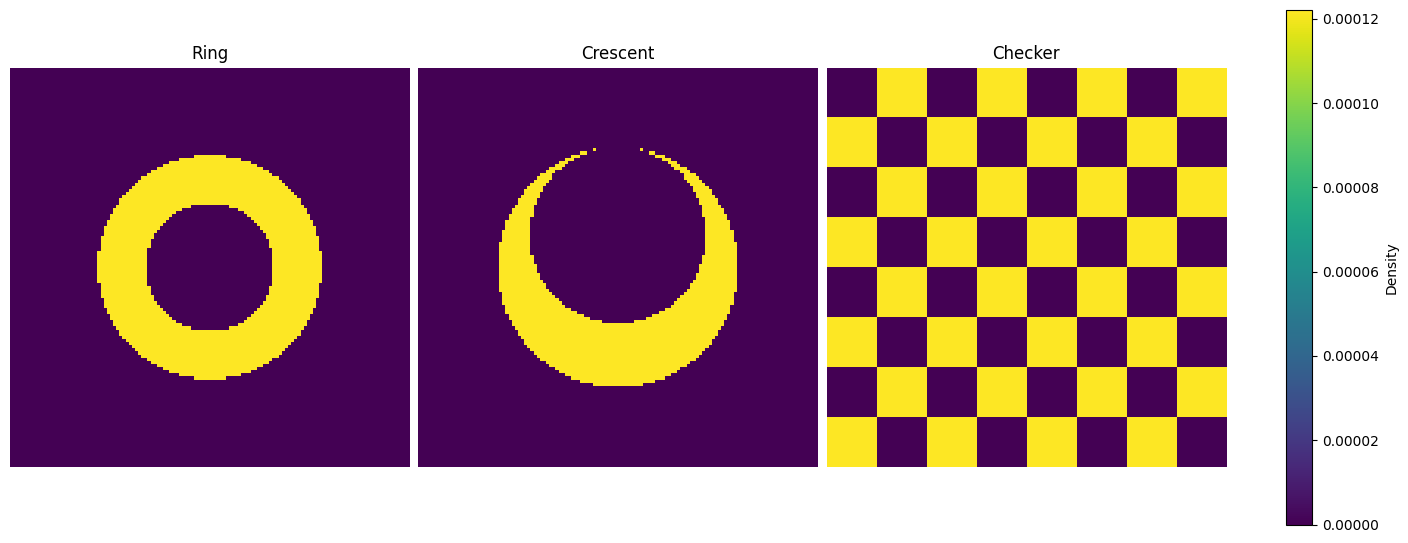

In [89]:
fig, axs = plt.subplots(1, 3, figsize=(14, 8), constrained_layout=True)

for idx, (name, density) in enumerate(shape_fields.items()):
    im = axs[idx].imshow(density, origin='lower')
    axs[idx].set_title(name)
    axs[idx].axis('off')
fig.colorbar(im, ax=axs.tolist(), shrink=0.65, label='Density')

In [90]:
def barycenter_sinkhorn(
        measures: jnp.ndarray,
        cost: jnp.ndarray,
        lambdas: jnp.ndarray,
        reg: float = 1e-3,
        tol: float = 1e-6,
        maxiter: int = 20,
        return_diagnostics: bool = False,
):
    lambdas = lambdas / lambdas.sum()
    # clip measures for log computations to be a little bit safer in practice
    log_measures = jnp.log(jnp.clip(measures, 1e-30))
    # lnb = jnp.log(jnp.clip(jnp.asarray(measures[0]), 1e-30))
    lnb = jnp.zeros_like(measures[0])
    lnK = -cost / reg

    def cond_fn(state):
        i, lnus, lnvs, lnb = state
        return i < maxiter

    def body_fn(state):
        i, lnus, lnvs, lnb = state
        # update each f^j
        lnus = log_measures - logsumexp(
            lnvs[:, None, :] + lnK[None, :, :],
            axis=2,
        )
        # compute log(K^T u^j) in a stable way
        ln_Ktu = logsumexp(
            lnus[:, :, None] + lnK[None, :, :],
            axis=1,
        )
        # update barycenter log(b)
        lnb = jnp.sum(lambdas[:, None] * ln_Ktu, axis=0)
        lnb = lnb - logsumexp(lnb)   # now renormalize
        # update each g^j
        lnvs = lnb[None, :] - ln_Ktu
        return (i+1, lnus, lnvs, lnb)
    
    lnus = jnp.zeros_like(measures)
    lnvs = jnp.zeros_like(measures)
    init_state = (jnp.asarray(0), lnus, lnvs, lnb)
    final_state = lax.while_loop(cond_fn, body_fn, init_state)
    iterations, lnus, lnvs, lnb = final_state
    b = jnp.exp(lnb)
    b /= b.sum()
    diagnostics = {
        "iterations": iterations,
        **({
            "ln_u": lnus,
            "ln_v": lnvs,
            "ln_b": lnb,
            } if return_diagnostics else {}),
        }
    return b, diagnostics

In [91]:
lambdas = jnp.array([1/3, 1/3, 1/3])
meas_array = jnp.asarray([j.reshape(-1) for j in measures_weights])
print(f"{meas_array.shape=}")
solution = barycenter_sinkhorn(
    measures=meas_array,
    cost=cost_matrix,
    lambdas=lambdas,
    reg=1e-4,
    tol=1e-4,
    maxiter=100,
)

b = solution[0]
print(F"{b.shape=}")
print(f"iterations = {solution[1]['iterations']}")

meas_array.shape=(3, 16384)
b.shape=(16384,)
iterations = 100


density.shape=(128, 128)
density.shape=(128, 128)
density.shape=(128, 128)
density.shape=(128, 128)


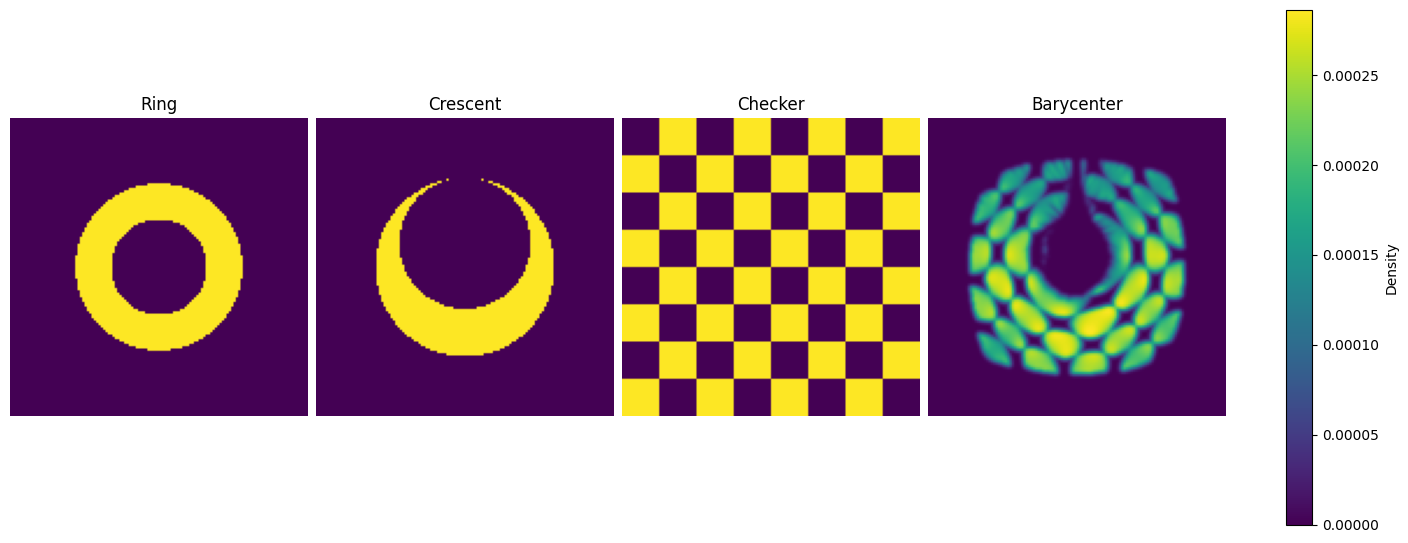

In [92]:
fig, axs = plt.subplots(1, 4, figsize=(14, 8), constrained_layout=True)

shape_fields['Barycenter'] = b.reshape((grid_size, grid_size))

for idx, (name, density) in enumerate(shape_fields.items()):
    print(f"{density.shape=}")
    im = axs[idx].imshow(density, origin='lower')
    axs[idx].set_title(name)
    axs[idx].axis('off')
fig.colorbar(im, ax=axs.tolist(), shrink=0.65, label='Density')